In [2]:
import batsim
import galsim
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] ='cm'
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('axes', unicode_minus=False)
plt.rc('axes.formatter', use_mathtext=True)

Intrinsic alignment (IA) has been shown previously to exhibit increasing amplitude with galaxy radius (Georgiou+2019, Singh+Mandelbaum2015). The result of this, is that different shears will be measured depending on the sensitivty of a shear estimator to different radii within the galaxy.

In order to represent this effect, BATSim's IA transform scales shear as a function of distance from the center of a galaxy. We base our model on the results of one of the previous studies.

# Georgiou 2019 best-fit

In this notebook, we carry out the best fit to the results of [Georgiou 2019](https://www.aanda.org/articles/aa/full_html/2019/08/aa35810-19/aa35810-19.html) which is used to set the default parameters of our non-affine IA shear model.

We then go on to show a few examples of how different parameter choices change the resulting shear profile.

In [3]:
# Parameters from G19
r_scale = np.array([0.5, 1.0, 1.25, 1.5, 2.0]) # weight function of estimator
r_iso = np.array([1.33, 2.66, 3.32, 3.99, 5.32]) # isophote radius (3-sigma)
A_obs = np.array([2.17e-4, 2.95e-4, 4.33e-4, 5.92e-4, 7.84e-4]) # measured alignment amplitude
sig_A = np.array([8.5e-5, 9.2e-5, 1.06e-4, 1.20e-4, 1.63e-4]) # error in alignment amplitude

r_wf = r_scale * r_iso

# Construct power law model to fit to the data
def A_model(r, A0, beta):
    return A0 * r**beta

# Fit the model to the data
popt, pcov = curve_fit(A_model, r_scale, A_obs, sigma=sig_A, absolute_sigma=True)

r_scale_fit = np.linspace(0.5, 2.0, 100)
A_fit = A_model(r_scale_fit, *popt)
A_upper = A_model(r_scale_fit, *(popt + np.sqrt(np.diag(pcov))))
A_lower = A_model(r_scale_fit, *(popt - np.sqrt(np.diag(pcov))))

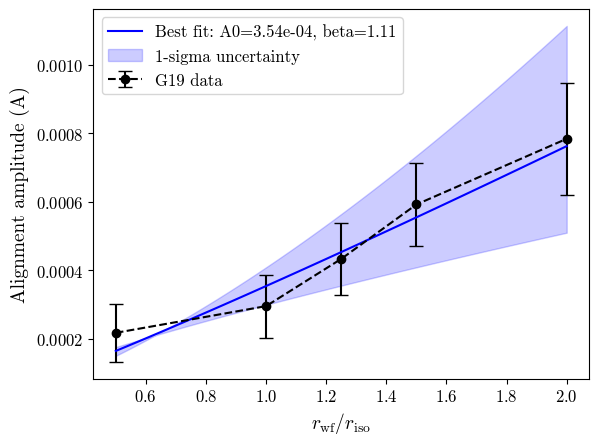

In [4]:
plt.errorbar(r_scale, A_obs, yerr=sig_A, marker='o', capsize=5, label='G19 data', color='black', ls='--')
plt.plot(r_scale_fit, A_fit, label=f'Best fit: A0={popt[0]:.2e}, beta={popt[1]:.2f}', color='blue')
plt.fill_between(r_scale_fit, A_lower, A_upper, color='blue', alpha=0.2, label='1-sigma uncertainty')
plt.xlabel(r'$r_{\rm wf}/r_{\rm iso}$', fontsize=14)
plt.ylabel(r'Alignment amplitude (A)', fontsize=14)
#plt.title('Best Fit of Alignment Amplitude vs Weight Function Scale')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.legend(fontsize=12)
plt.savefig('IA_model_G19_bestfit.pdf', dpi=300, bbox_inches='tight')

## Applying G19 fit to simulations

As discussed in the release paper, we make a phenonmenological reparameterisation of the model fit to G19 in order to use it within BATSim for generating shear values. This is done by replacing $r_{wf}/r_{iso}$ with $r/r_{hlr}$ where $r$ is distance from the centre of the galaxy and $r_{hlr}$ is half-light radius.

It is important to note that typically $r_{iso}$ is larger than $r_{hlr}$. As such, the model employed in BATSim is intended only to reproduce the observed trend in alignment signal with galaxy radius. The functional form of this model is

$$A_{\rm IA}(r/r_{hlr}) = A_0 \times (r/r_{hlr})^b$$

we then take

$$|g| = A_{\rm IA}$$

For simplicity and to clearly demonstrate the shear pattern created by this model, we show the shear values produced by the model on a quiver plot grid and apply the transfrom to an initially circular galaxy then plot the galaxy and isophotes to illustrate increasing ellipticity with radius.

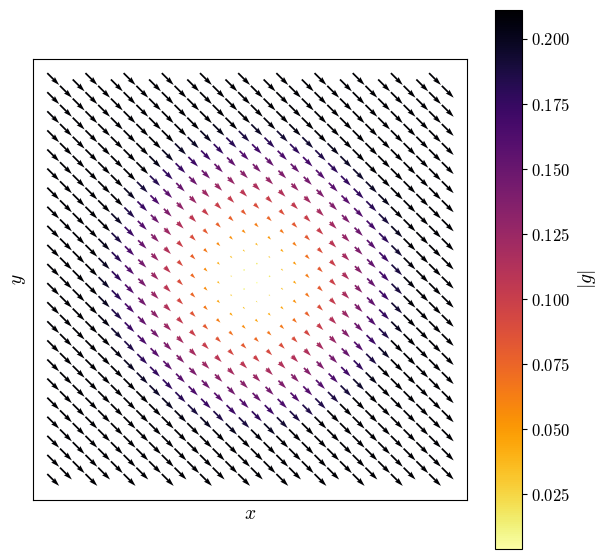

In [8]:
# Set image parameters
pix_scale = 0.2
npix = 64

# Set galaxy hlr to be used in the IA model
hlr = 1.0
pos_angle = -45.0

# Construct IA transfrom object. We scale the amplitude
# by two orders of magnitude to make the effect more
# obvious visually.
ia_transform = batsim.IATransform(
    A=popt[0]*100,
    scale=pix_scale,
    hlr=hlr,
    phi=np.radians(pos_angle)
)

# Construct coordinate stamp. This is the internal function used to set-up 
# coordinate grids during rendering, but we expose it via the public API
# as it can be useful for other purposes and validation tests.
stamp = batsim.Stamp(nn=npix, scale=pix_scale)
coords = stamp.coords
x = coords[0]
y = coords[1]

# Get shear values at each set of coords from IA transfrom object
g1, g2 = ia_transform.get_g1g2(x, y)

# Determine the size and orientation of the arrows to plot
g_abs = np.hypot(g1, g2)
phi_plot = 0.5 * np.arctan2(g2, g1)

u = g_abs * np.cos(phi_plot)
v = g_abs * np.sin(phi_plot)

# Downsample to avoid plotting 4096 overlapping arrows.
step = 6

# Quiver plot
fig, ax = plt.subplots(figsize=(7, 7))

q = ax.quiver(
    x[::step],
    y[::step],
    u[::step],
    v[::step],
    np.hypot(u[::step], v[::step]),
    angles="xy",
    scale_units="xy",
    scale=0.4, # smaller scale produces longer arrows
    width=0.004, # smaller width produces thinner arrows
    cmap="inferno_r",
    pivot="middle",
)

ax.set_aspect("equal")
ax.set_xlabel(r"$x$", fontsize=14)
ax.set_ylabel(r"$y$", fontsize=14)
ax.set_xticks([])
ax.set_yticks([])
cb = fig.colorbar(q, ax=ax, label=r"$|g|$")
cb.set_label(r"$|g|$", fontsize=14)
cb.ax.tick_params(labelsize=12)
fig.savefig('IA_model_G19_quiver.pdf', dpi=300, bbox_inches='tight')
plt.show()

In this set-up, we set the alignment orientation to be towards the bottom left of the image. We use the default G19 best fit values. This results in peak shear values on the order of $10^{-3}$.

The length and colour of the arrows in the quiver plot represent the strength of the shear.

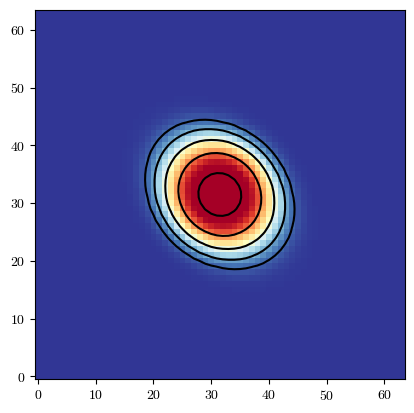

In [18]:
# Apply transform to a galaxy image and plot residuals
gal = galsim.Gaussian(half_light_radius=hlr)

# Simulate galaxy image with IA transform using BATSim
gal_ia_image = batsim.simulate_galaxy(
    gal_obj=gal,
    transform_obj=ia_transform,
    scale=pix_scale,
    ngrid=npix
)

# Call batsim plotting utilities to make nicely normalised plot
fig = batsim.pltutil.make_plot_image(gal_ia_image)

# Plot isophotes
contours = np.geomspace(0.0001, 1, 10)
plt.contour(gal_ia_image, levels=contours, colors='black')

The alignment amplitude used here is highly exagerated, but the radial dependence of the shear can clearly be seen in the resulting image. The black contours are galaxy isophotes, which clearly increase in elliptiicty at large radii.

Next let's change the parameters of our transform more, to see how it changes the resulting shear. First, we'll increase the value of the power, to give a greater gradient in shear as a function of radius.

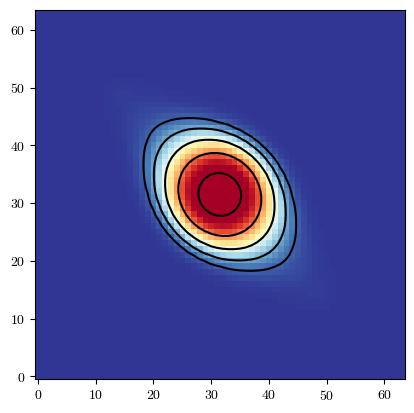

In [28]:
# Define new IATransform with different model parameters
ia_transform = batsim.IATransform(
    A=popt[0]*100, # keep amplitude the same
    beta=1.6, # increase power to give greater gradient in shear
    scale=pix_scale,
    hlr=hlr,
    phi=np.radians(pos_angle)
)

# Simulate galaxy image with IA transform using BATSim
gal_ia_image = batsim.simulate_galaxy(
    gal_obj=gal,
    transform_obj=ia_transform,
    scale=pix_scale,
    ngrid=npix
)

# Call batsim plotting utilities to make nicely normalised plot
fig = batsim.pltutil.make_plot_image(gal_ia_image)

# Plot isophotes
contours = np.geomspace(0.0001, 1, 10)
plt.contour(gal_ia_image, levels=contours, colors='black')

Finally, let's look at how to apply shear to galaxies that are not at the image center. We'll shift our Galsim profile by 2 pixels in x and y. The ``center`` arguement of ``IATransform`` specifies where to move the shear field in the image. ``IATransform`` treats the image center as ``[0,0]`` and the center arguement specifes **coordinates in the image to center the shear field at rather than how far from the center to shift**. As such, be careful that wherever you are shifting the Galsim profile lines up with where you center the shear field

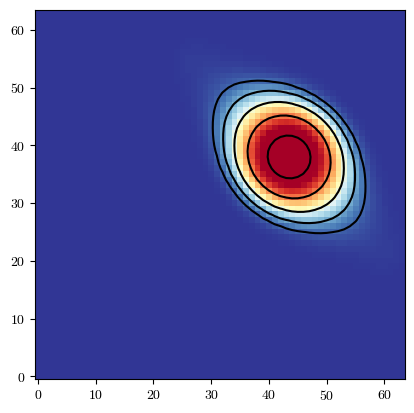

In [42]:
# Shift galaxy center to illustrate how to move the shear field
gal_shift = gal.shift(dx=2.4,dy=1.3)

# get galaxy centroid to make sure we place the IATransform correctly
center = gal_shift.centroid

# Define new IATransform with different model parameters
ia_transform = batsim.IATransform(
    A=popt[0]*100, # keep amplitude the same
    beta=1.6, # increase power to give greater gradient in shear
    scale=pix_scale,
    hlr=hlr,
    phi=np.radians(pos_angle),
    center=[center.x, center.y] # re-center the shear field at the new galaxy center.
)

# Simulate galaxy image with IA transform using BATSim
gal_ia_image = batsim.simulate_galaxy(
    gal_obj=gal_shift,
    transform_obj=ia_transform,
    scale=pix_scale,
    ngrid=npix
)

# Call batsim plotting utilities to make nicely normalised plot
fig = batsim.pltutil.make_plot_image(gal_ia_image)

# Plot isophotes
contours = np.geomspace(0.0001, 1, 10)
plt.contour(gal_ia_image, levels=contours, colors='black')